In [128]:
## Imprting all of the modules I need
import math
import numpy as np
import matplotlib.pyplot as plt
import thermal
import pandas as pd
import MLM
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['text.usetex'] = False
from matplotlib import colors

In [129]:
## Custom CMAP (Color blind friendly)
mycolors = ["#4477AA", "#66CCEE", "#228833", "#CCBB44", "#EE6677", "#AA3377", "#BBBBBB"]
my_cmap = LinearSegmentedColormap.from_list("my_Festom_cmap", mycolors)

In [130]:
## Reading the Data files for the element plot files
Cu = pd.read_csv("Cu_cond.csv")
Ni = pd.read_csv("Ni_cond.csv")
Al = pd.read_csv("Al_cond.csv")
Fe = pd.read_csv("Fe_cond.csv")

In [131]:
### I wrote this code but was having trouble getting a single colorbar. I put this code through chatGPT and it generated the code 
### in the cell below. That graph is what I used on my paper.

### -----------------------------------------------------------------------------------------------------------------------------

# # ## Graphing the conductivities of the different elements
# fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# obj1 = ax[0][0].scatter(Fe["log10(rho)"], Cu["log10(con)"], s=20, c = Cu["T(K)"], cmap = my_cmap, label ="LeeMore")
# obj2 = ax[0][1].scatter(Ni["log10(rho)"], Ni["log10(con)"], s=20, c = Ni["T(K)"], cmap = my_cmap, label ="LeeMore")
# obj3 = ax[1][0].scatter(Al["log10(rho)"], Al["log10(con)"], s=20, c = Al["T(K)"], cmap = my_cmap, label ="LeeMore")
# obj4 = ax[1][1].scatter(Fe["log10(rho)"], Fe["log10(con)"], s=20, c = Fe["T(K)"], cmap = my_cmap, label ="LeeMore")
# ax[0][0].set_xlabel("Density (g/cc)")
# ax[1][0].set_xlabel("Density (g/cc)")
# ax[1][1].set_xlabel("Density (g/cc)")
# ax[0][1].set_xlabel("Density (g/cc)")
# ax[0][0].set_ylabel("Conductivity (S/m)")
# ax[1][0].set_ylabel("Conductivity (S/m)")
# ax[1][1].set_ylabel("Conductivity (S/m)")
# ax[0][1].set_ylabel("Conductivity (S/m)")
# ax[0][0].set_title("Copper")
# ax[1][0].set_title("Aluminum")
# ax[0][1].set_title("Nickel")
# ax[0][0].set_title("Iron")
# # fig.colorbar(obj1, ax=ax[0][0])
# # fig.colorbar(obj2, ax=ax[0][1])
# # fig.colorbar(obj3, ax=ax[1][0])
# # fig.colorbar(obj4, ax=ax[1][1])


# # create a single norm to be shared across all images
# norm = colors.Normalize(vmin=5000, vmax=40000)


# fig.subplots_adjust(right=0.8)
# fig.colorbar(mappable=ax, norm = norm, cmap = "plasma")
# plt.tight_layout()
# plt.savefig("Different Elements.png", dpi = 800)

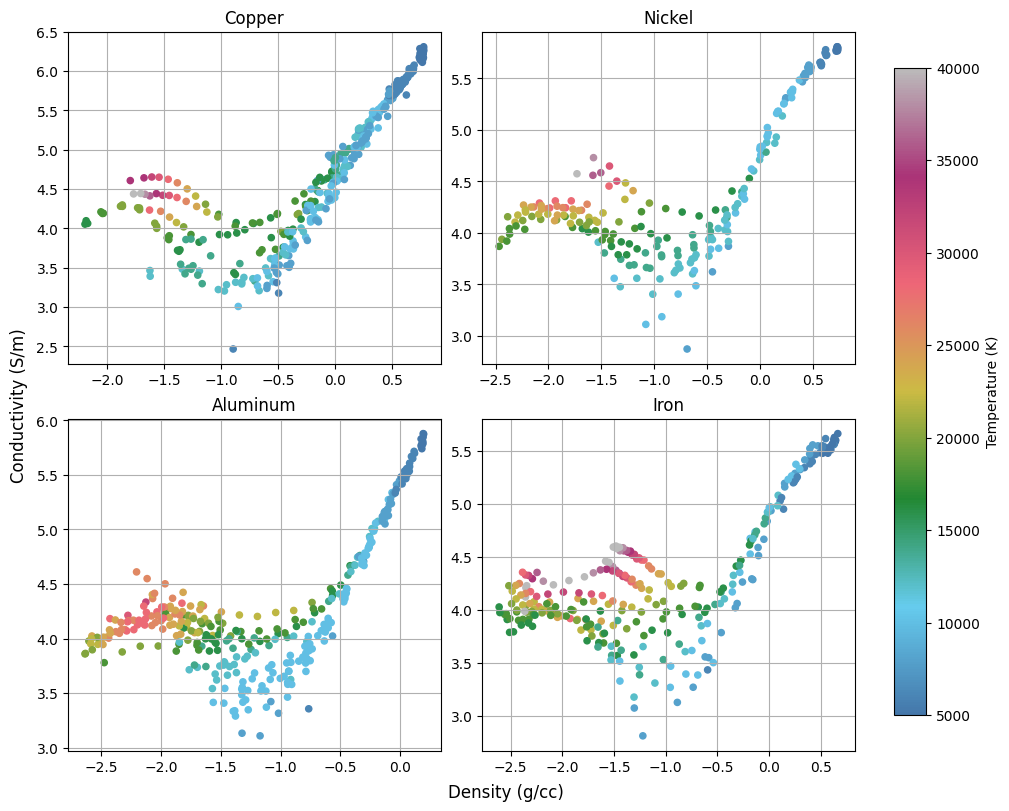

In [132]:
## This code was generated from ChatGPT from my original code above since I was having trouble doing 1 colorbar. 
## Some of it has been edited by me to add titles and grid lines

import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Use constrained_layout to avoid overlap
fig, ax = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# Shared normalization
norm = colors.Normalize(vmin=5000, vmax=40000)

# Scatter plots
obj1 = ax[0][0].scatter(Cu["log10(rho)"], Cu["log10(con)"],
                        s=20, c=Cu["T(K)"], cmap=my_cmap, norm=norm)

obj2 = ax[0][1].scatter(Ni["log10(rho)"], Ni["log10(con)"],
                        s=20, c=Ni["T(K)"], cmap=my_cmap, norm=norm)

obj3 = ax[1][0].scatter(Al["log10(rho)"], Al["log10(con)"],
                        s=20, c=Al["T(K)"], cmap=my_cmap, norm=norm)

obj4 = ax[1][1].scatter(Fe["log10(rho)"], Fe["log10(con)"],
                        s=20, c=Fe["T(K)"], cmap=my_cmap, norm=norm)

# # Labels
# for a in ax.flat:
#     a.set_xlabel("Density (g/cc)")
#     a.set_ylabel("Conductivity (S/m)")

# Titles
ax[0][0].set_title("Copper")
ax[0][1].set_title("Nickel")
ax[1][0].set_title("Aluminum")
ax[1][1].set_title("Iron")
ax[0][0].grid(which="major")
ax[1][0].grid(which="major")
ax[0][1].grid(which="major")
ax[1][1].grid(which="major")


# Shared colorbar (no overlap now)
cbar = fig.colorbar(obj1, ax=ax, location='right', shrink=0.9)
cbar.set_label("Temperature (K)")
fig.supxlabel("Density (g/cc)")
fig.supylabel("Conductivity (S/m)")

plt.savefig("Different Elements.png", dpi=800)
plt.show()

In [133]:
## Testing My Spitzer Code
## Getting the mass density, conductivity, temp, Z and A
rhoCu = np.array(10 ** Cu["log10(rho)"]) ## rho and cond are in log form so I need to undo that
CondCu = np.array(10 ** Cu["log10(con)"])/100 ## The conductivity in in S/m to I am dividing by a factor of 100 to get into S/cm since this is in CGS
TCu = np.array(Cu["T(K)"])
ZCu = np.array(Cu["Z"])
ACu = 63.55

rhoFe = np.array(10 ** Fe["log10(rho)"])
CondFe = np.array(10 ** Fe["log10(con)"])/100
TFe = np.array(Fe["T(K)"])
ZFe = np.array(Fe["Z"])
AFe  = 55.845

rhoNi = np.array(10 ** Ni["log10(rho)"])
CondNi = np.array(10 ** Ni["log10(con)"])/100
TNi = np.array(Ni["T(K)"])
ZNi = np.array(Ni["Z"])
ANi = 58.6934

rhoAl = 10 ** Al["log10(rho)"]
CondAl = np.array(10 ** Al["log10(con)"])/100
TAl = Al["T(K)"]
ZAl = Al["Z"]
AAl = 26.982

In [134]:
## Function to go from mass density to ion density
## (g/cc) / (g/mol) * 1/mol = 1/cc
def rhoTon(rho, A):
    m_proton = 1.6726e-24
    ion_density = rho/(A*m_proton)
    return ion_density

convert = 9e9 ## This is a conversion factor from S/m to s^-1. I don't think I actually use it

In [135]:
nionCu = rhoTon(rhoCu, ACu)
nionNi = rhoTon(rhoNi, ANi)
nionAl = rhoTon(rhoAl, AAl)
nionFe = rhoTon(rhoFe, AFe)

## Electron density is nele = nion * Z

## Spitzer conductivity using my code
sigmaLSAl = [thermal.Conductivity(TAl[i], TAl[i], nionAl[i], ZAl[i]*nionAl[i], ZAl[i], AAl).SpitzerElectricConductivity() for i in range(len(TAl))]
sigmaLSCu = [thermal.Conductivity(TCu[i], TCu[i], nionCu[i], ZCu[i]*nionCu[i], ZCu[i], ACu).SpitzerElectricConductivity() for i in range(len(TCu))]
sigmaLSNi = [thermal.Conductivity(TNi[i], TNi[i], nionNi[i], ZNi[i]*nionNi[i], ZNi[i], ANi).SpitzerElectricConductivity() for i in range(len(TNi))]
sigmaLSFe = [thermal.Conductivity(TFe[i], TFe[i], nionFe[i], ZFe[i]*nionFe[i], ZFe[i], AFe).SpitzerElectricConductivity() for i in range(len(TFe))]


In [136]:
## Electrical Conductivity of Different Models Modified LeeMore
## Input for MLM functions have temperature in eV
sigmaMLMAl = [MLM.sigma(ZAl[i], AAl, rhoAl[i], TAl[i]/11600) for i in range(len(TAl))]
sigmaMLMCu = [MLM.sigma(ZCu[i], ACu, rhoCu[i], TCu[i]/11600) for i in range(len(TCu))]
sigmaMLMNi = [MLM.sigma(ZNi[i], ANi, rhoNi[i], TNi[i]/16000) for i in range(len(TNi))]
sigmaMLMFe = [MLM.sigma(ZFe[i], AFe, rhoFe[i], TFe[i]/11600)for i in range(len(TFe))]


## Regular LeeMore Model
sigmaLMAl = [MLM.sigma_LM(TAl[i]/11600, TAl[i]/11600, nionAl[i], ZAl[i]) for i in range(len(TAl))]
sigmaLMCu = [MLM.sigma_LM(TCu[i]/11600, TCu[i]/11600, nionCu[i], ZCu[i]) for i in range(len(TCu))]
sigmaLMNi = [MLM.sigma_LM(TNi[i]/11600, TNi[i]/11600, nionNi[i], ZNi[i]) for i in range(len(TNi))]
sigmaLMFe = [MLM.sigma_LM(TFe[i]/11600, TFe[i]/11600, nionFe[i], ZFe[i]) for i in range(len(TFe))]

In [137]:
### This code I wrote and then I used ChatGPT to make it have 1 single legend. I am commenting this out

# # Use constrained_layout to avoid overlap
# fig, ax = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# # Shared normalization
# norm = colors.Normalize(vmin=5000, vmax=40000)


# # Scatter plots
# # Quadrant 1
# ax[0][0].scatter(rhoCu, sigmaLMCu,
#                         s=20, c="#D81B60", label = "LeeMore", edgecolor = "#740E34")
# ax[0][0].scatter(rhoCu, sigmaMLMCu,
#                         s=20, c="#B9DEFF90", label = "Modified LeeMore", edgecolor = "#42C0FF")
# ax[0][0].scatter(rhoCu, sigmaLSCu,
#                         s=20, c="#FFC107", label = "Spizter", edgecolor = "#987303")
# ax[0][0].scatter(rhoCu, CondCu,
#                         s=20, c="#004D40", label = "Experiment",edgecolor = "#0E3B34")
# ax[0][0].set_title("Copper")
# ax[0][0].set_yscale("log")
# ax[0][0].legend()
# ax[0][0].grid(which="major")

# ## Quadrant 2
# ax[0][1].scatter(rhoNi, sigmaLMNi,
#                         s=20, c="#D81B60", label = "LeeMore", edgecolor = "#740E34")
# ax[0][1].scatter(rhoNi, sigmaMLMNi,
#                         s=20, c="#B9DEFF90", label = "Modified LeeMore", edgecolor = "#42C0FF")
# ax[0][1].scatter(rhoNi, sigmaLSNi,
#                         s=20, c="#FFC107", label = "Spizter", edgecolor = "#987303")
# ax[0][1].scatter(rhoNi, CondNi,
#                         s=20, c="#004D40", label = "Experiment",edgecolor = "#0E3B34")
# ax[0][1].set_title("Nickel")
# ax[0][1].set_yscale("log")
# ax[0][1].legend()
# ax[0][1].grid(which="major")


# ## Quadrant 3
# ax[1][0].scatter(rhoAl, sigmaLMAl,
#                         s=20, c="#D81B60", label = "LeeMore", edgecolor = "#740E34")
# ax[1][0].scatter(rhoAl, sigmaMLMAl,
#                         s=20, c="#B9DEFF90", label = "Modified LeeMore", edgecolor = "#42C0FF")
# ax[1][0].scatter(rhoAl, sigmaLSAl,
#                         s=20, c="#FFC107", label = "Spizter", edgecolor = "#987303")
# ax[1][0].scatter(rhoAl, CondAl,
#                         s=20, c="#004D40", label = "Experiment",edgecolor = "#0E3B34")
# ax[1][0].set_title("Aluminum")
# ax[1][0].set_yscale("log")
# ax[1][0].legend()
# ax[1][0].grid(which="major")

# ## Quadrant 4
# ax[1][1].scatter(rhoFe, sigmaLMFe,
#                         s=20, c="#D81B60", label = "LeeMore", edgecolor = "#740E34")
# ax[1][1].scatter(rhoFe, sigmaMLMFe,
#                         s=20, c="#B9DEFF90", label = "Modified LeeMore", edgecolor = "#42C0FF")
# ax[1][1].scatter(rhoFe, sigmaLSFe,
#                         s=20, c="#FFC107", label = "Spizter", edgecolor = "#987303")
# ax[1][1].scatter(rhoFe, CondFe,
#                         s=20, c="#004D40", label = "Experiment",edgecolor = "#0E3B34")
# ax[1][1].set_title("Iron")
# ax[1][1].set_yscale("log")
# ax[1][1].legend()
# ax[1][1].grid(which="major")

# # Labels
# for a in ax.flat:
#     a.set_xlabel("Density (g/cc)")
#     a.set_ylabel("Conductivity (S/m)")


# fig.suptitle('Conductivities Models', fontsize = 20)

# plt.savefig("Different Elements.png", dpi=800)
# plt.show()

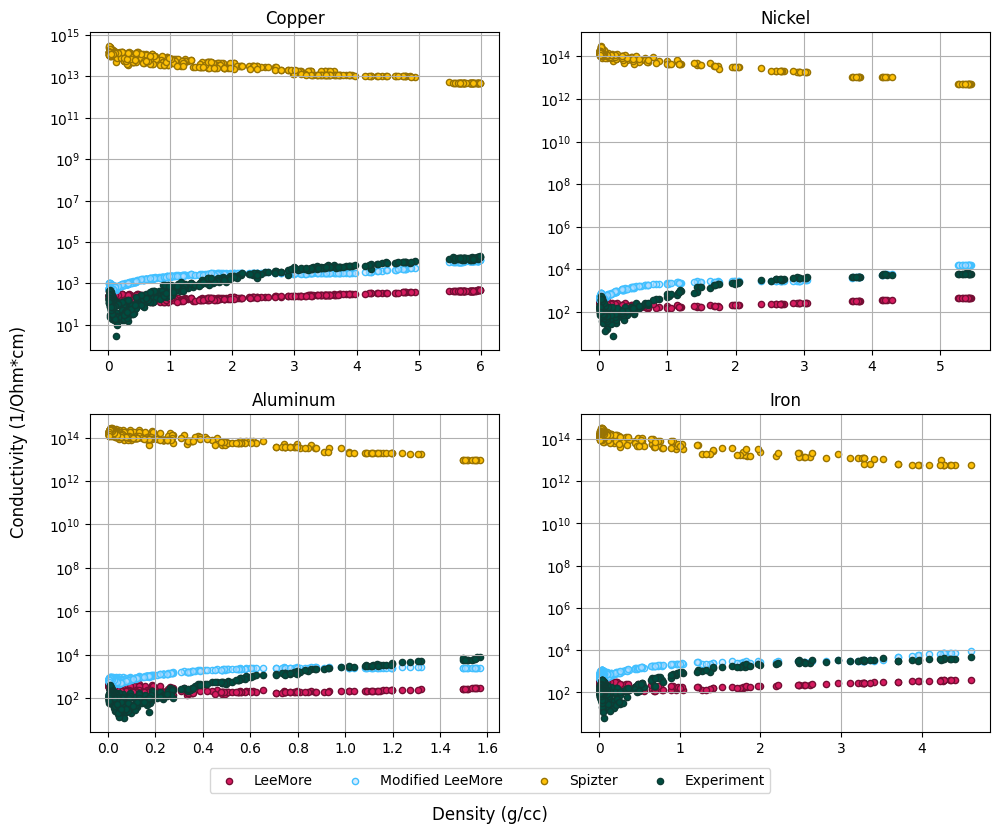

In [138]:
# Use constrained_layout to avoid overlap
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Shared normalization
norm = colors.Normalize(vmin=5000, vmax=40000)

# --- Store handles for legend ---
handles = []
labels = []

# Quadrant 1 (use this to define legend entries)
h1 = ax[0][0].scatter(rhoCu, sigmaLMCu,
                     s=20, c="#D81B60", label="LeeMore", edgecolor="#740E34")
h2 = ax[0][0].scatter(rhoCu, sigmaMLMCu,
                     s=20, c="#B9DEFF90", label="Modified LeeMore", edgecolor="#42C0FF")
h3 = ax[0][0].scatter(rhoCu, sigmaLSCu,
                     s=20, c="#FFC107", label="Spizter", edgecolor="#987303")
h4 = ax[0][0].scatter(rhoCu, CondCu,
                     s=20, c="#004D40", label="Experiment", edgecolor="#0E3B34")

handles = [h1, h2, h3, h4]
labels = [h.get_label() for h in handles]

ax[0][0].set_title("Copper")
ax[0][0].set_yscale("log")
ax[0][0].grid(which="major")

# Quadrant 2
ax[0][1].scatter(rhoNi, sigmaLMNi, s=20, c="#D81B60", edgecolor="#740E34")
ax[0][1].scatter(rhoNi, sigmaMLMNi, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[0][1].scatter(rhoNi, sigmaLSNi, s=20, c="#FFC107", edgecolor="#987303")
ax[0][1].scatter(rhoNi, CondNi, s=20, c="#004D40", edgecolor="#0E3B34")
ax[0][1].set_title("Nickel")
ax[0][1].set_yscale("log")
ax[0][1].grid(which="major")

# Quadrant 3
ax[1][0].scatter(rhoAl, sigmaLMAl, s=20, c="#D81B60", edgecolor="#740E34")
ax[1][0].scatter(rhoAl, sigmaMLMAl, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[1][0].scatter(rhoAl, sigmaLSAl, s=20, c="#FFC107", edgecolor="#987303")
ax[1][0].scatter(rhoAl, CondAl, s=20, c="#004D40", edgecolor="#0E3B34")
ax[1][0].set_title("Aluminum")
ax[1][0].set_yscale("log")
ax[1][0].grid(which="major")

# Quadrant 4
ax[1][1].scatter(rhoFe, sigmaLMFe, s=20, c="#D81B60", edgecolor="#740E34")
ax[1][1].scatter(rhoFe, sigmaMLMFe, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[1][1].scatter(rhoFe, sigmaLSFe, s=20, c="#FFC107", edgecolor="#987303")
ax[1][1].scatter(rhoFe, CondFe, s=20, c="#004D40", edgecolor="#0E3B34")
ax[1][1].set_title("Iron")
ax[1][1].set_yscale("log")
ax[1][1].grid(which="major")

# REMOVE individual axis labels
for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")

# Figure-level labels (NEW)
fig.supxlabel("Density (g/cc)")
fig.supylabel("Conductivity (1/Ohm*cm)")
fig.subplots_adjust(top=1)
fig.subplots_adjust(bottom=0.125)
fig.subplots_adjust(right=1)
fig.subplots_adjust(left=0.1)
# Legend
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           bbox_to_anchor=(0.5, 0.04))

plt.savefig("Different_Models.png", dpi=800, bbox_inches="tight")
plt.show()

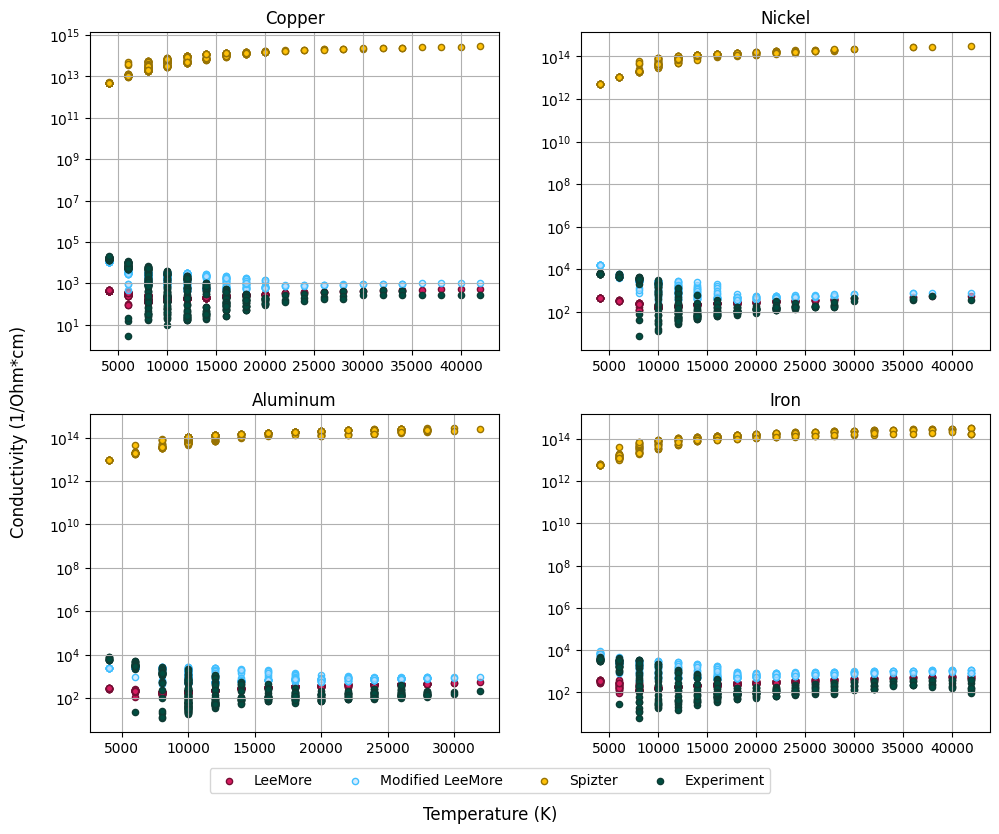

In [139]:
# Use constrained_layout to avoid overlap
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Shared normalization
norm = colors.Normalize(vmin=5000, vmax=40000)

# --- Store handles for legend ---
handles = []
labels = []

# Quadrant 1 (use this to define legend entries)
h1 = ax[0][0].scatter(TCu, sigmaLMCu,
                     s=20, c="#D81B60", label="LeeMore", edgecolor="#740E34")
h2 = ax[0][0].scatter(TCu, sigmaMLMCu,
                     s=20, c="#B9DEFF90", label="Modified LeeMore", edgecolor="#42C0FF")
h3 = ax[0][0].scatter(TCu, sigmaLSCu,
                     s=20, c="#FFC107", label="Spizter", edgecolor="#987303")
h4 = ax[0][0].scatter(TCu, CondCu,
                     s=20, c="#004D40", label="Experiment", edgecolor="#0E3B34")

handles = [h1, h2, h3, h4]
labels = [h.get_label() for h in handles]

ax[0][0].set_title("Copper")
ax[0][0].set_yscale("log")
ax[0][0].grid(which="major")

# Quadrant 2
ax[0][1].scatter(TNi, sigmaLMNi, s=20, c="#D81B60", edgecolor="#740E34")
ax[0][1].scatter(TNi, sigmaMLMNi, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[0][1].scatter(TNi, sigmaLSNi, s=20, c="#FFC107", edgecolor="#987303")
ax[0][1].scatter(TNi, CondNi, s=20, c="#004D40", edgecolor="#0E3B34")
ax[0][1].set_title("Nickel")
ax[0][1].set_yscale("log")
ax[0][1].grid(which="major")

# Quadrant 3
ax[1][0].scatter(TAl, sigmaLMAl, s=20, c="#D81B60", edgecolor="#740E34")
ax[1][0].scatter(TAl, sigmaMLMAl, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[1][0].scatter(TAl, sigmaLSAl, s=20, c="#FFC107", edgecolor="#987303")
ax[1][0].scatter(TAl, CondAl, s=20, c="#004D40", edgecolor="#0E3B34")
ax[1][0].set_title("Aluminum")
ax[1][0].set_yscale("log")
ax[1][0].grid(which="major")

# Quadrant 4
ax[1][1].scatter(TFe, sigmaLMFe, s=20, c="#D81B60", edgecolor="#740E34")
ax[1][1].scatter(TFe, sigmaMLMFe, s=20, c="#B9DEFF90", edgecolor="#42C0FF")
ax[1][1].scatter(TFe, sigmaLSFe, s=20, c="#FFC107", edgecolor="#987303")
ax[1][1].scatter(TFe, CondFe, s=20, c="#004D40", edgecolor="#0E3B34")
ax[1][1].set_title("Iron")
ax[1][1].set_yscale("log")
ax[1][1].grid(which="major")

# REMOVE individual axis labels
for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")

# Figure-level labels (NEW)
fig.supxlabel("Temperature (K)")
fig.supylabel("Conductivity (1/Ohm*cm)")
fig.subplots_adjust(top=1)
fig.subplots_adjust(bottom=0.125)
fig.subplots_adjust(right=1)
fig.subplots_adjust(left=0.1)
# Legend
fig.legend(handles, labels,
           loc="lower center",
           ncol=4,
           bbox_to_anchor=(0.5, 0.04))

plt.savefig("Different_Models_temperature.png", dpi=800, bbox_inches="tight")
plt.show()

In [140]:
## Declaring the parameters for a gas puff z pinch shell
Z, A, rho = 1, 2.01412, 2.7e-6
## This mass density I got from the peak liner in one of the papers I used
## I did 1 to 300 eV It could be wrong
nion = rhoTon(rho, A) 
nele = Z*nion
Tele = np.linspace(1, 300 , 10000) ## in eV

## Ekectrical Conductivity of Different Models
sigmaMLM = [MLM.sigma(Z, A, rho, Tele[i]) for i in range(len(Tele))]
sigmaLS = [thermal.Conductivity(Tele[i] * 11600, Tele[i]* 11600, nion, nele, Z, A).SpitzerElectricConductivity() for i in range(len(Tele))]
sigmaLM = [MLM.sigma_LM(Tele[i], Tele[i], nele, Z) for i in range(len(Tele))]

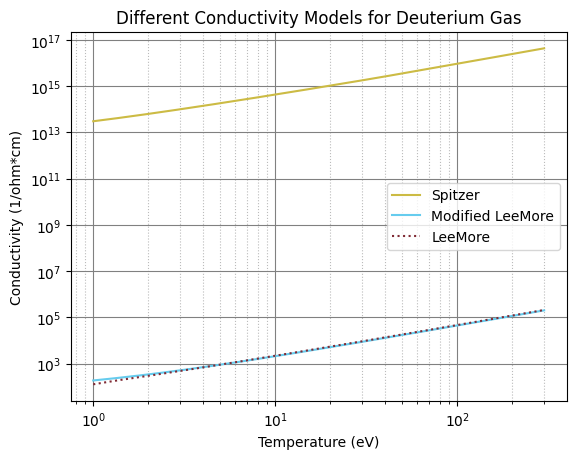

In [141]:
plt.plot(Tele, sigmaLS, c = "#CCBB44", label = "Spitzer")
plt.plot(Tele, sigmaMLM, c="#66CCEE", label = "Modified LeeMore")
plt.plot(Tele, sigmaLM, c = "#802B35",linestyle="dotted", label = "LeeMore")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("Conductivity (1/ohm*cm)")
plt.xlabel("Temperature (eV)")
plt.title("Different Conductivity Models for Deuterium Gas")
plt.grid(which="major", color='gray')
plt.grid(which="minor", linestyle=':', color = "#BBBBBB")
plt.legend()
plt.savefig("deuterium.png", dpi = 800)